### Case Study: Import Libraries
This cell imports essential libraries for data manipulation and numerical operations. `pandas` is used for working with DataFrames, and `numpy` is used for numerical computations.

In [1]:
import pandas as pd
import numpy as np

### Case Study: Load Data
This cell loads the dataset from the specified CSV file ('/content/train.csv.zip') into a pandas DataFrame named `df`.

In [2]:
df= pd.read_csv('/content/train.csv.zip')

### Case Study: Display DataFrame Information
This cell prints a concise summary of the DataFrame, including the column names, their data types, and the count of non-null values. This helps in quickly identifying missing values and understanding data types.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1117957 entries, 0 to 1117956
Data columns (total 22 columns):
 #   Column                           Non-Null Count    Dtype  
---  ------                           --------------    -----  
 0   id                               1117957 non-null  int64  
 1   MonsoonIntensity                 1117957 non-null  int64  
 2   TopographyDrainage               1117957 non-null  int64  
 3   RiverManagement                  1117957 non-null  int64  
 4   Deforestation                    1117957 non-null  int64  
 5   Urbanization                     1117957 non-null  int64  
 6   ClimateChange                    1117957 non-null  int64  
 7   DamsQuality                      1117957 non-null  int64  
 8   Siltation                        1117957 non-null  int64  
 9   AgriculturalPractices            1117957 non-null  int64  
 10  Encroachments                    1117957 non-null  int64  
 11  IneffectiveDisasterPreparedness  1117957 non-null 

### Case Study: Check for Missing Values
This cell calculates and displays the number of missing (null) values for each column in the DataFrame. A value of 0 indicates no missing data in that column.

In [4]:
df.isnull().sum()

,0
id,0
MonsoonIntensity,0
TopographyDrainage,0
RiverManagement,0
Deforestation,0
Urbanization,0
ClimateChange,0
DamsQuality,0
Siltation,0
AgriculturalPractices,0


### Case Study: Display DataFrame Shape
This cell returns a tuple representing the dimensions of the DataFrame, showing the number of rows and columns, respectively.

In [5]:
df.shape

(1117957, 22)

### Case Study: Display Data Types
This cell shows the data type of each column in the DataFrame, which is crucial for data preprocessing and model building.

In [6]:
df.dtypes

,0
id,int64
MonsoonIntensity,int64
TopographyDrainage,int64
RiverManagement,int64
Deforestation,int64
Urbanization,int64
ClimateChange,int64
DamsQuality,int64
Siltation,int64
AgriculturalPractices,int64


### Case Study: Display Entire DataFrame
This cell prints the entire DataFrame, providing a comprehensive view of the data. For large DataFrames, only a truncated view is shown by default.

In [7]:
df

,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,0,5,8,5,8,6,4,4,3,3,...,5,3,3,5,4,7,5,7,3,0.445
1,1,6,7,4,4,8,8,3,5,4,...,7,2,0,3,5,3,3,4,3,0.450
2,2,6,5,6,7,3,7,1,5,4,...,7,3,7,5,6,8,2,3,3,0.530
3,3,3,4,6,5,4,8,4,7,6,...,2,4,7,4,4,6,5,7,5,0.535
4,4,5,3,2,6,4,4,3,3,3,...,2,2,6,6,4,1,2,3,5,0.415
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1117952,1117952,3,3,4,10,4,5,5,7,10,...,7,8,7,2,2,1,4,6,4,0.495
1117953,1117953,2,2,4,3,9,5,8,1,3,...,9,4,4,3,7,4,9,4,5,0.480
1117954,1117954,7,3,9,4,6,5,9,1,3,...,5,5,5,5,6,5,5,2,4,0.485
1117955,1117955,7,3,3,7,5,2,3,4,6,...,6,8,5,3,4,6,7,6,4,0.495


### Case Study: Feature Engineering Setup
This cell imports `matplotlib.pyplot` and `seaborn` for plotting. It then defines a list of `features` by excluding 'id' and 'FloodProbability' from the DataFrame columns, as 'id' is an identifier and 'FloodProbability' is the target variable.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


features = [col for col in df.columns if col not in ['id', 'FloodProbability']]


### Case Study: Feature Distribution Histograms
This loop generates a histogram for each feature to visualize its distribution. `kde=True` adds a kernel density estimate for a smoother representation of the distribution. This helps in understanding the spread and skewness of individual features.

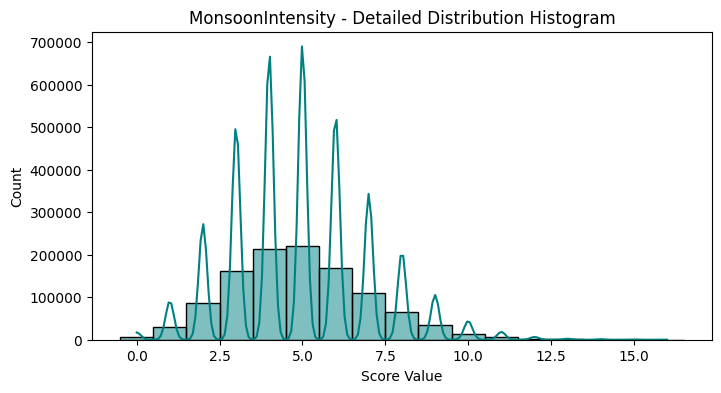

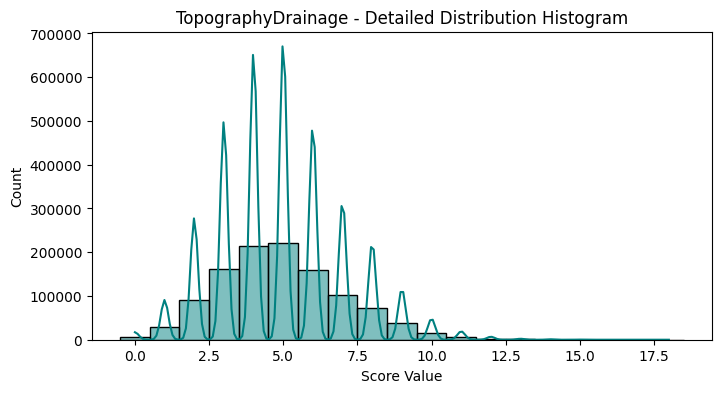

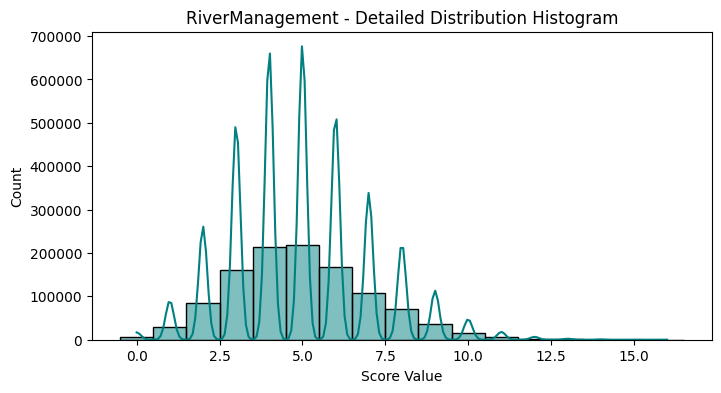

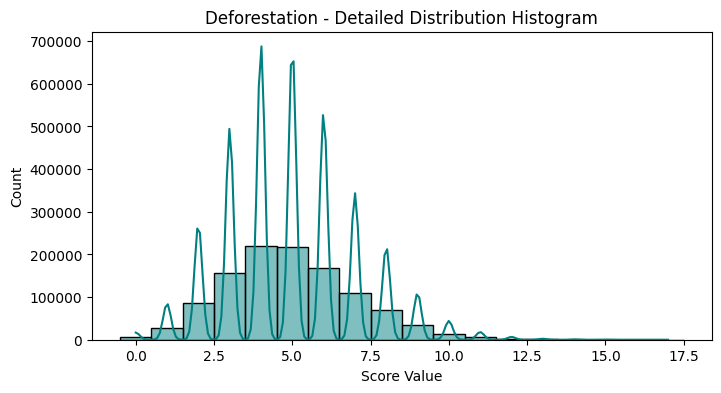

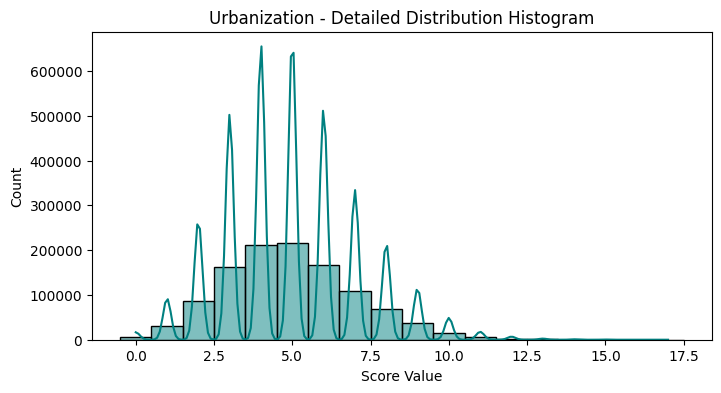

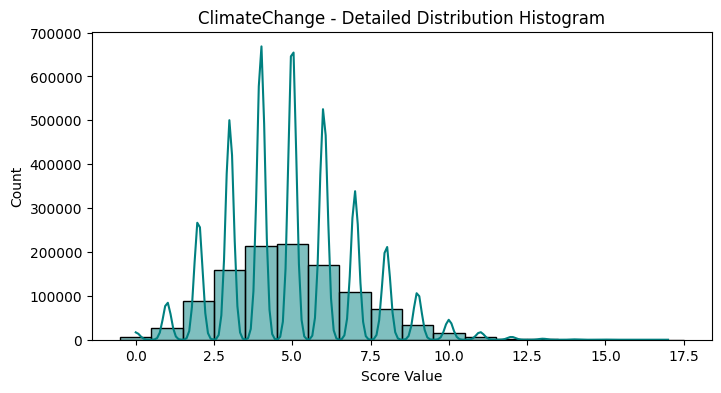

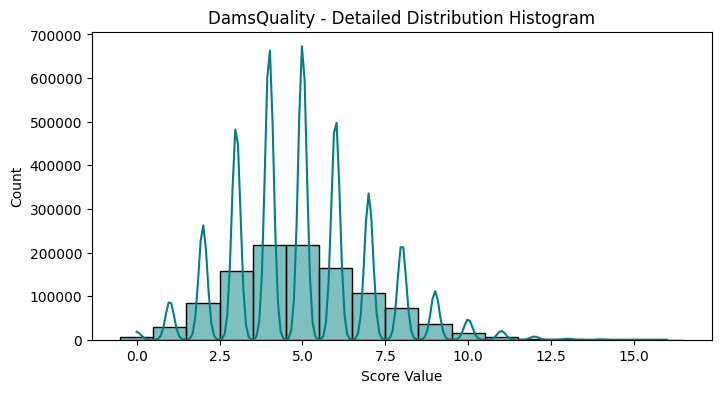

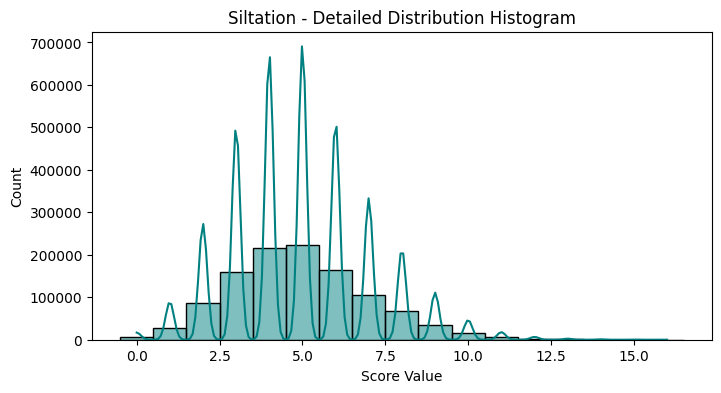

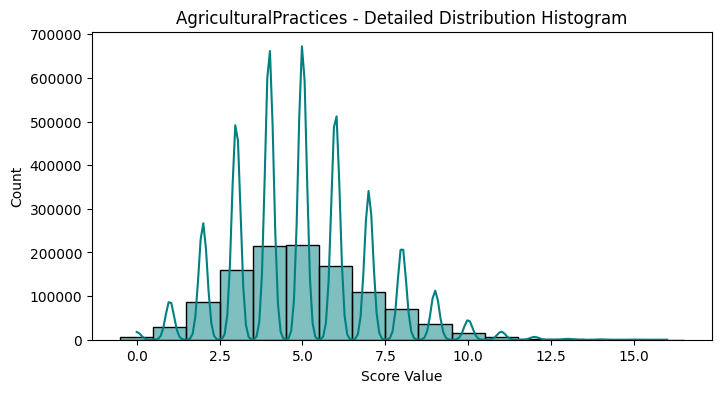

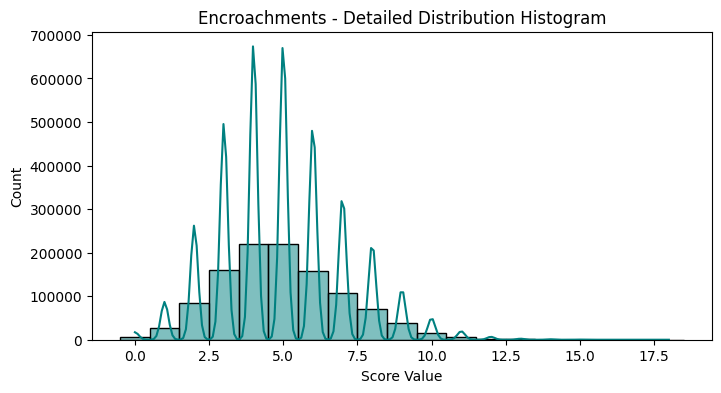

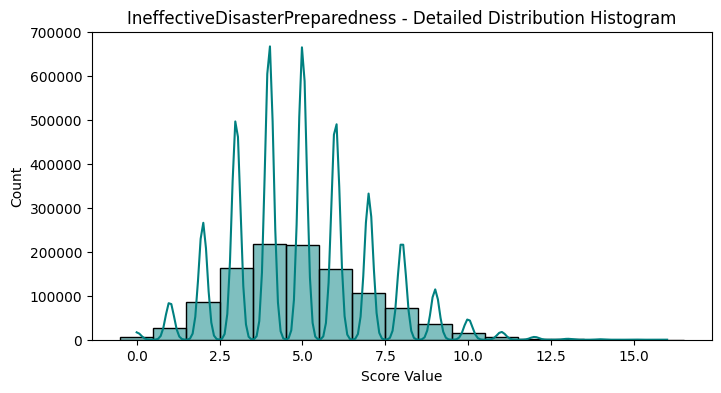

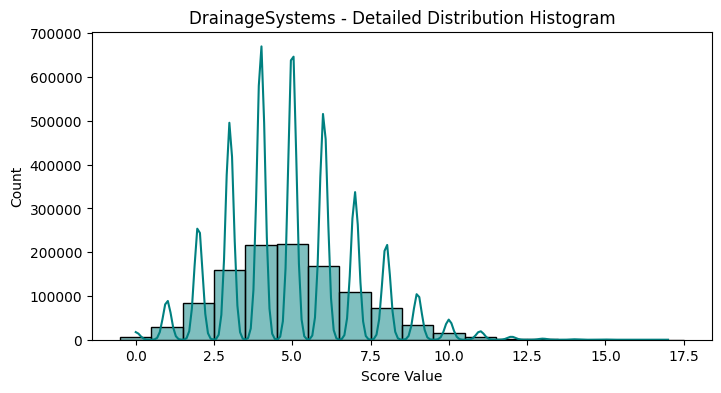

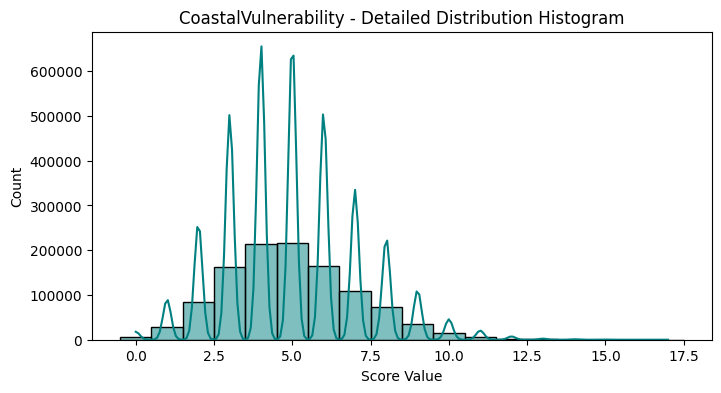

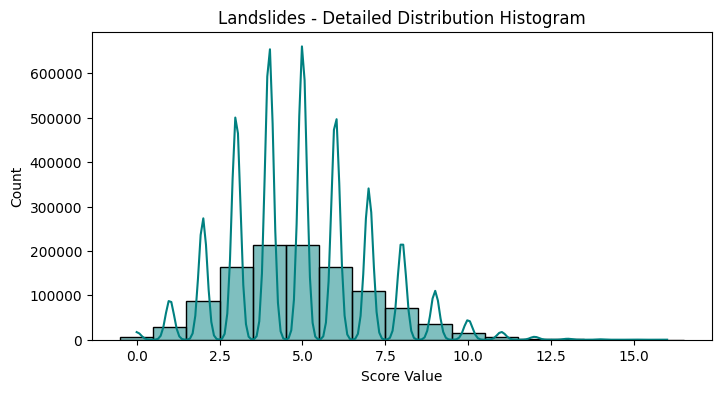

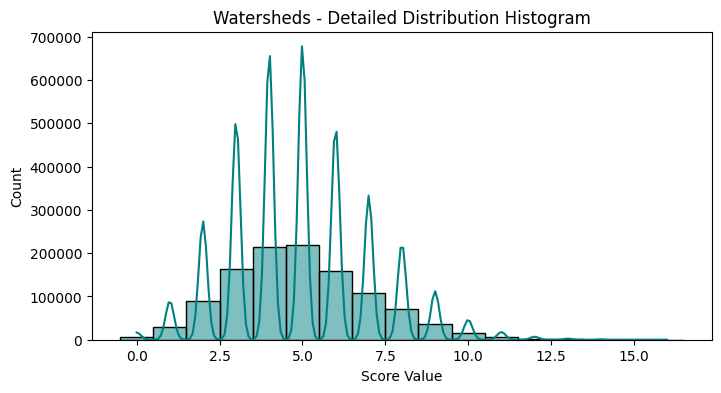

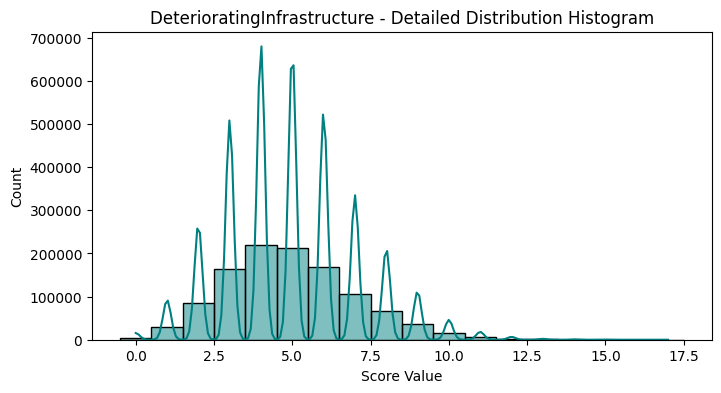

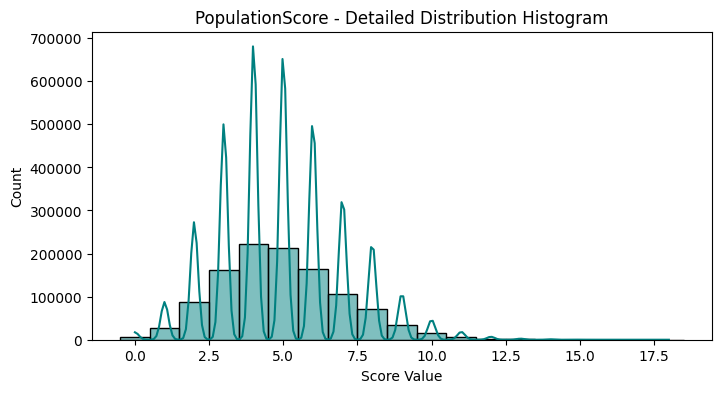

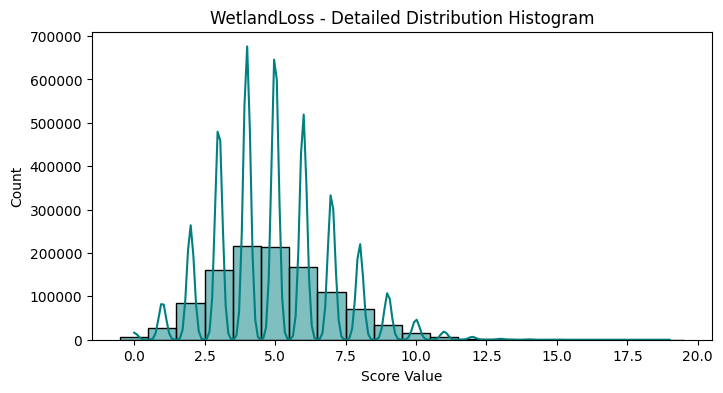

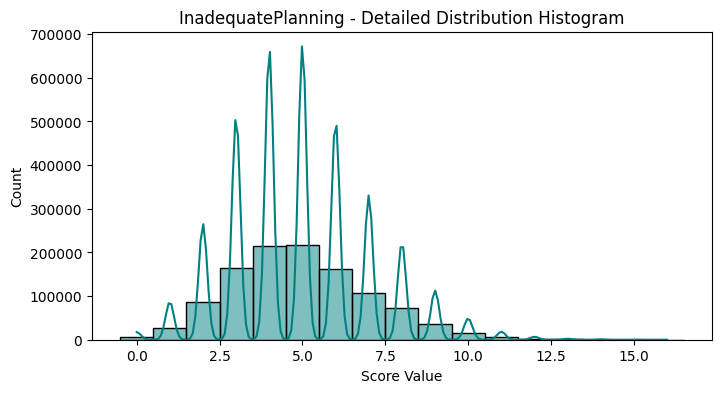

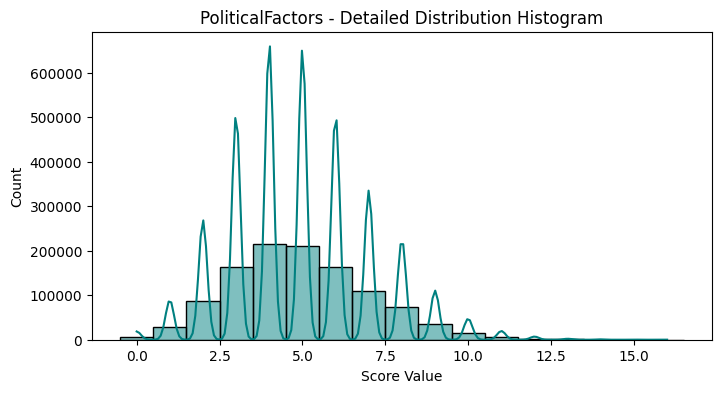

In [9]:
for col in features:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True, bins=15, color='teal', discrete=True)
    plt.title(f'{col} - Detailed Distribution Histogram')
    plt.xlabel('Score Value')
    plt.ylabel('Count')
    plt.show()


### Case Study: Feature Box Plots for Outlier Detection
This loop creates box plots for each feature. Box plots are excellent for visualizing the distribution of numerical data and identifying potential outliers (points outside the 'whiskers').

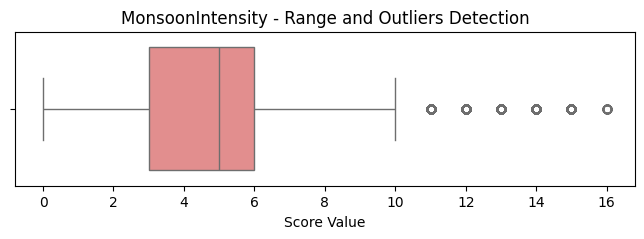

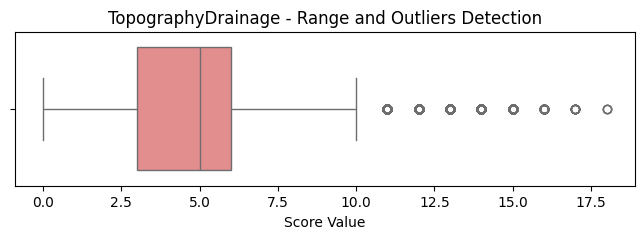

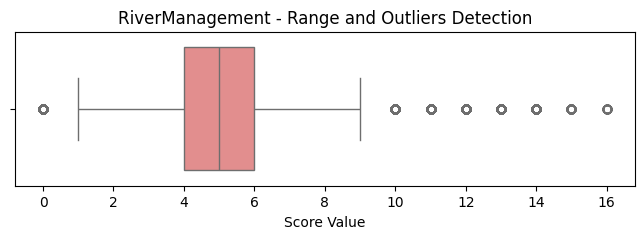

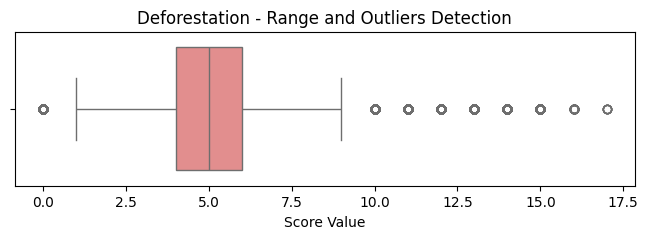

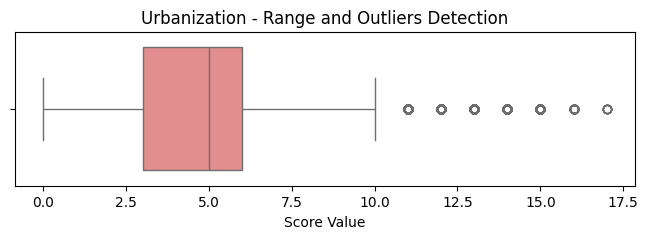

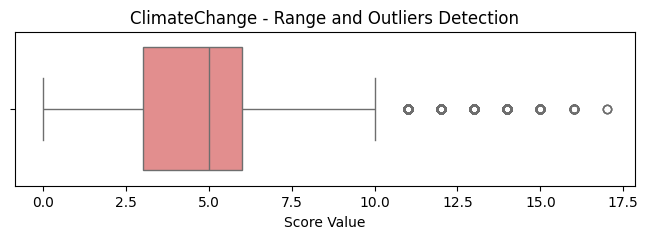

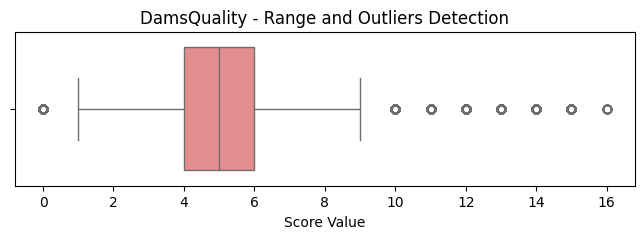

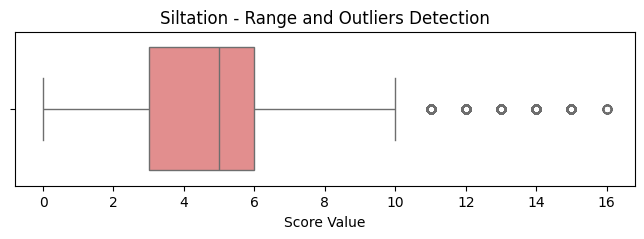

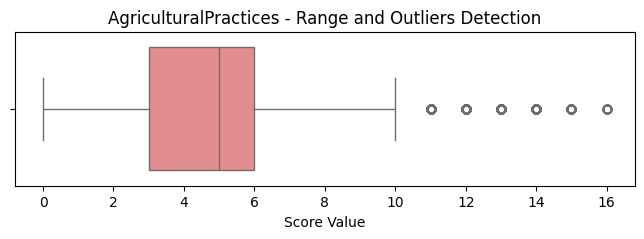

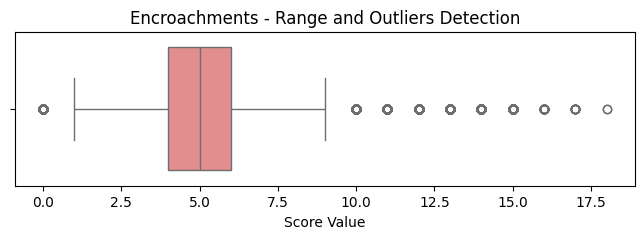

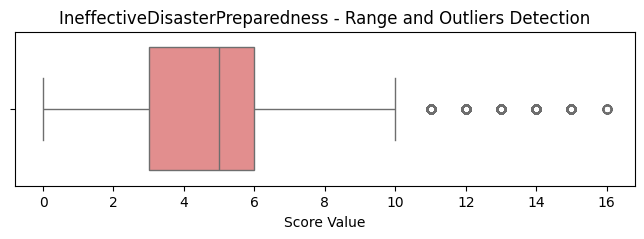

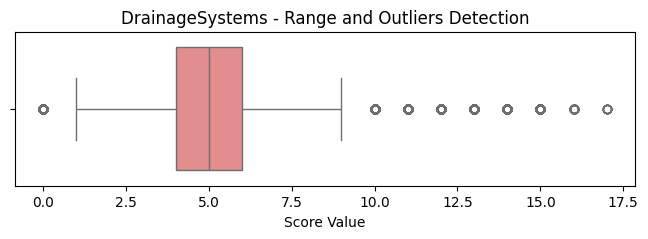

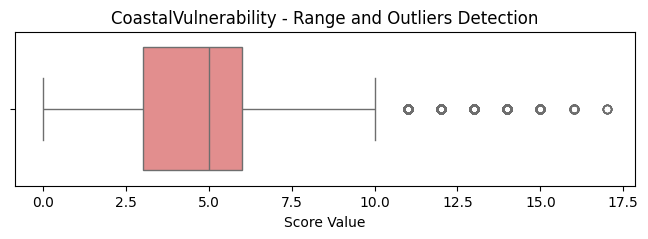

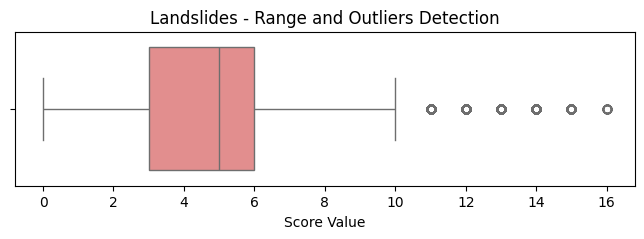

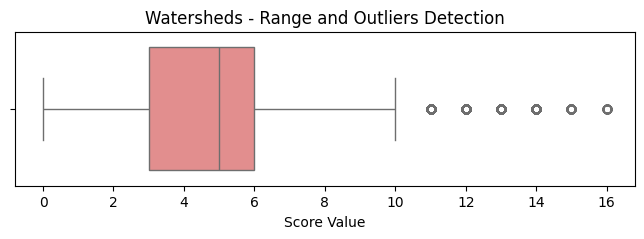

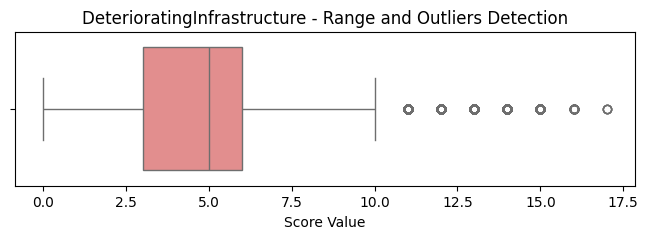

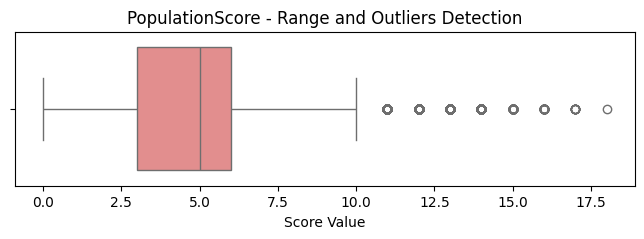

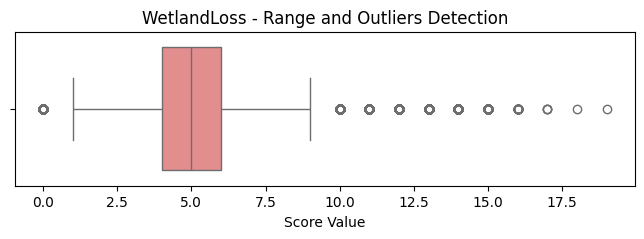

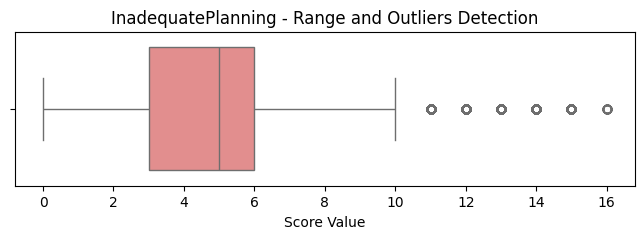

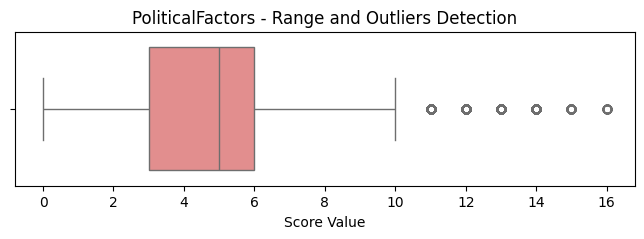

In [10]:
for col in features:
    plt.figure(figsize=(8, 2))
    sns.boxplot(x=df[col], color='lightcoral')
    plt.title(f'{col} - Range and Outliers Detection')
    plt.xlabel('Score Value')
    plt.show()


### Case Study: Target Variable Distribution
This cell plots a histogram of the 'FloodProbability' target variable with a kernel density estimate. This helps to understand the distribution of the target variable and check for balance or skewness.

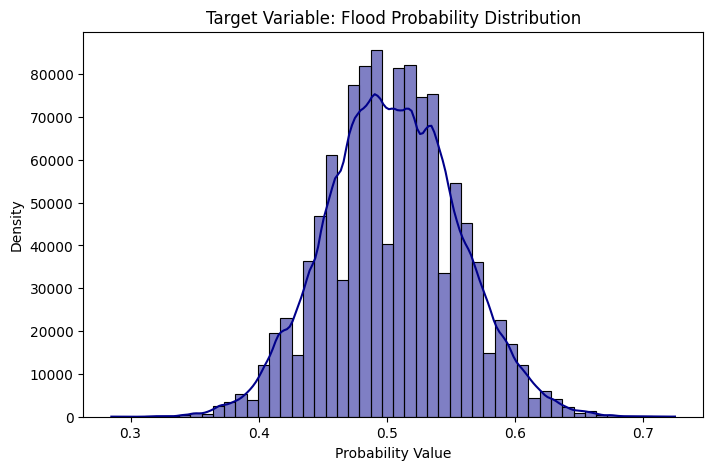

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(df['FloodProbability'], kde=True, bins=50, color='darkblue')

plt.title('Target Variable: Flood Probability Distribution')
plt.xlabel('Probability Value')
plt.ylabel('Density')
plt.show()


### Case Study: Outlier Removal
This cell creates a copy of the DataFrame (`df_cleaned`) and then iteratively removes outliers from each feature using the Interquartile Range (IQR) method. Rows where any feature falls outside `Q1 - 1.5 * IQR` and `Q3 + 1.5 * IQR` are removed. It then prints the shape of the DataFrame before and after outlier removal to show the impact.

In [12]:
df_cleaned = df.copy()

for col in features:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df_cleaned = df_cleaned[(df_cleaned[col] >= lower_limit) & (df_cleaned[col] <= upper_limit)]

print("Pehle data ka size:", df.shape)
print("Outliers hatane ke baad data ka size:", df_cleaned.shape)


Pehle data ka size: (1117957, 22)
Outliers hatane ke baad data ka size: (710971, 22)


### Case Study: Outlier Capping
This cell creates another copy of the DataFrame (`df_capped`) and handles outliers by capping them rather than removing the rows. Values below the `lower_limit` are set to `lower_limit`, and values above the `upper_limit` are set to `upper_limit`. This preserves the number of rows while mitigating the effect of extreme values.

In [13]:
df_capped = df.copy()

for col in features:
    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df_capped[col] = np.where(df_capped[col] < lower_limit, lower_limit, df_capped[col])
    df_capped[col] = np.where(df_capped[col] > upper_limit, upper_limit, df_capped[col])

print("Capping complete ho gayi hai! Kisi bhi row ko drop nahi kiya gaya.")


Capping complete ho gayi hai! Kisi bhi row ko drop nahi kiya gaya.


### Case Study: Boxplots After Outlier Removal
This cell generates box plots for all features in the `df_cleaned` DataFrame. This visualization confirms that outliers have been addressed (removed in this case) and provides a clearer view of the cleaned data distributions.

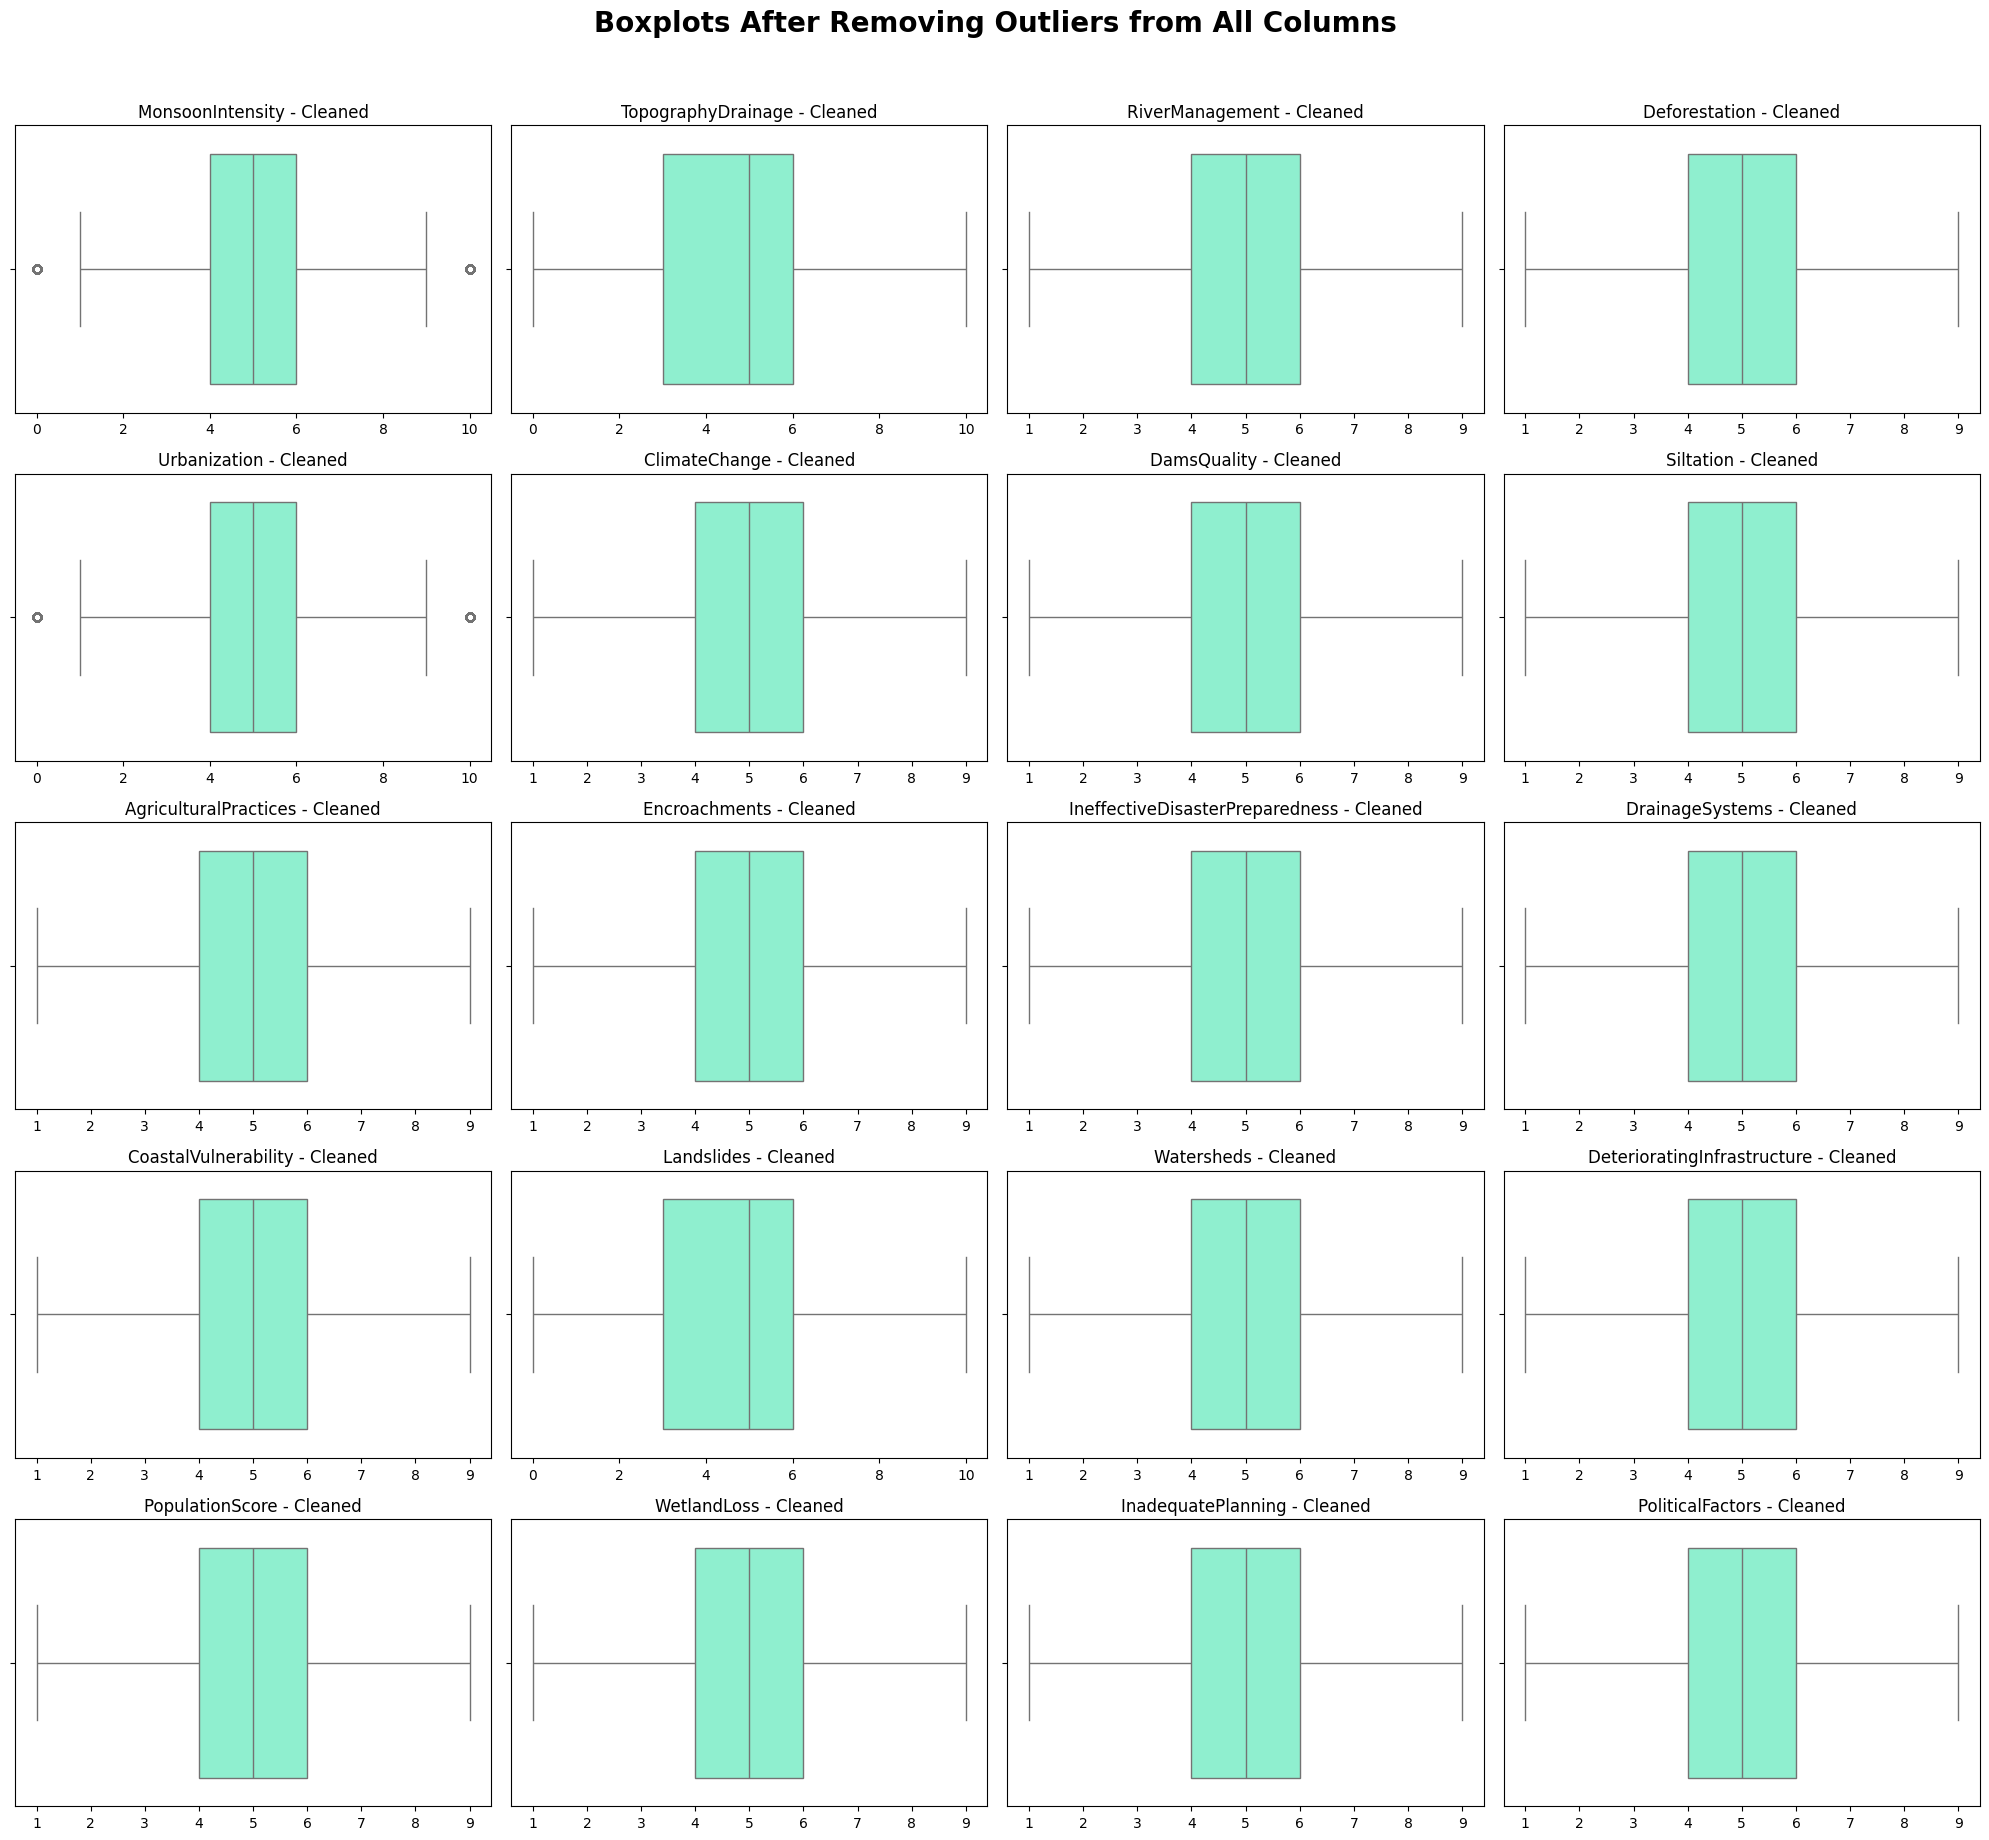

In [14]:
fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(20, 18))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(x=df_cleaned[col], ax=axes[i], color='aquamarine')
    axes[i].set_title(f'{col} - Cleaned', fontsize=12)
    axes[i].set_xlabel('')

plt.suptitle('Boxplots After Removing Outliers from All Columns', fontsize=20, weight='bold', y=1.02)
plt.tight_layout()
plt.show()


### Case Study: Feature Correlation Heatmap
This cell loads the original data again into `df_cleaned` and then generates a correlation heatmap for a sampled subset of features. This helps visualize the linear relationships between different features, which can be useful for feature selection or understanding multicollinearity.

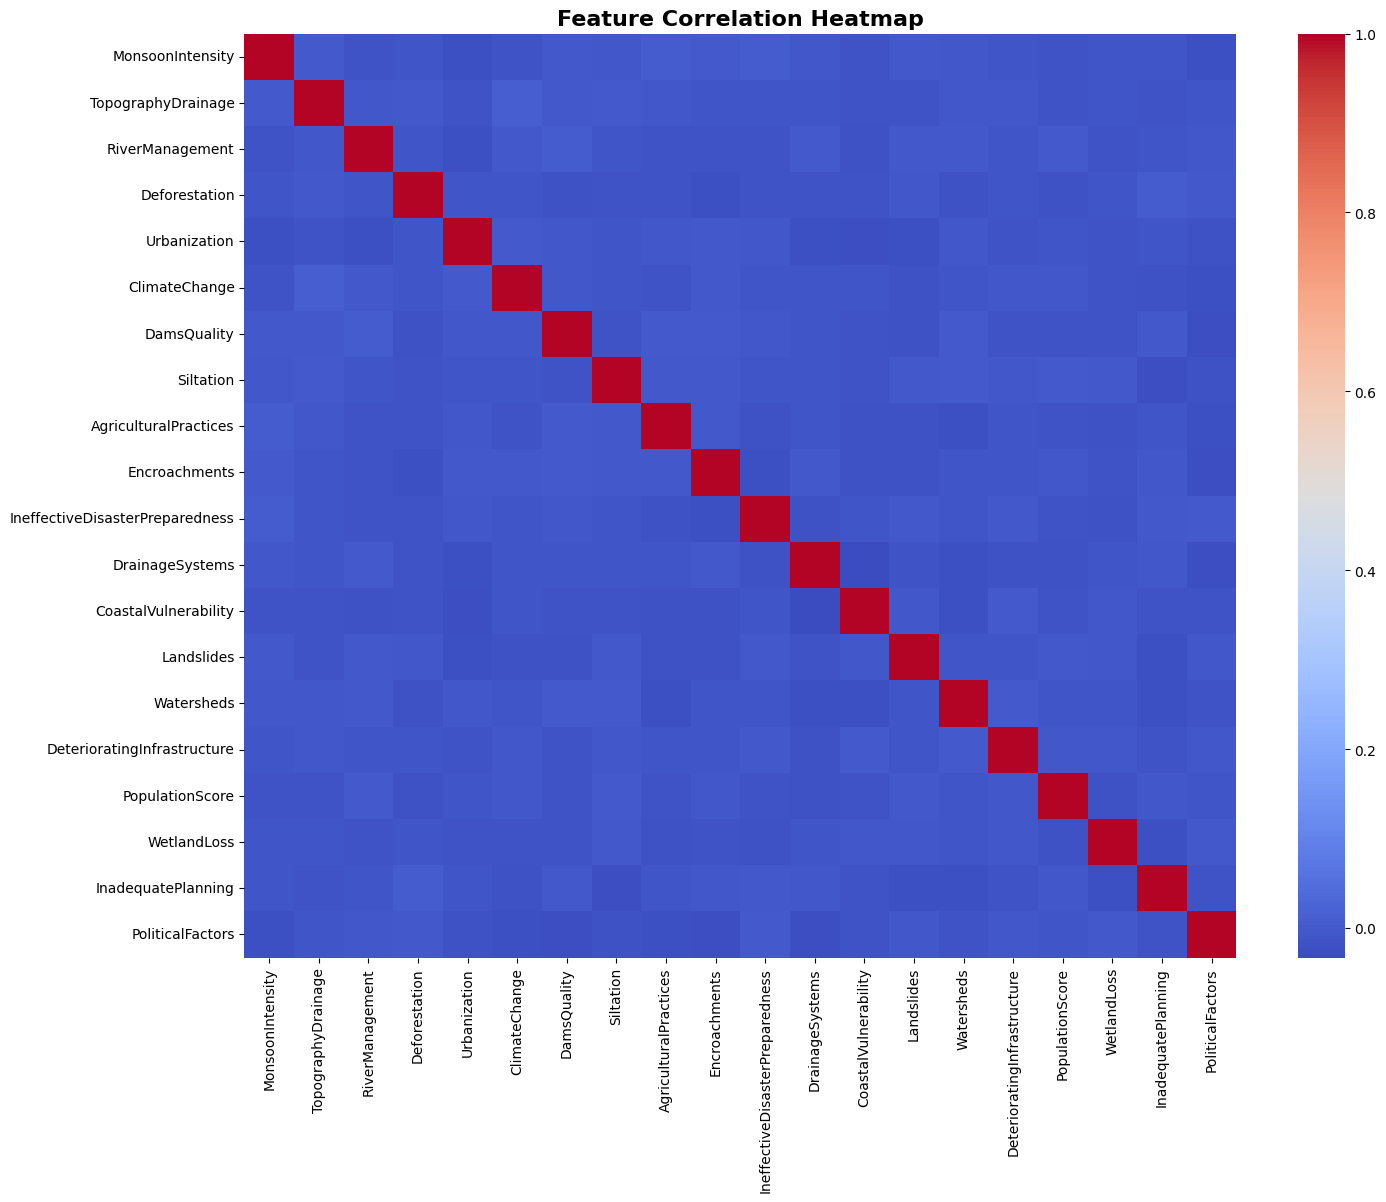

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_cleaned = pd.read_csv('/content/train.csv.zip')
features = [col for col in df_cleaned.columns if col not in ['id', 'FloodProbability']]

plt.figure(figsize=(16, 12))
sns.heatmap(df_cleaned[features].sample(20000, random_state=42).corr(), cmap='coolwarm', annot=False, cbar=True)
plt.title('Feature Correlation Heatmap', fontsize=16, weight='bold')
plt.show()


### Case Study: Target Variable Box Plot
This cell creates a box plot specifically for the 'FloodProbability' target variable. This visualization helps to understand the spread, central tendency, and any outliers in the target variable itself.

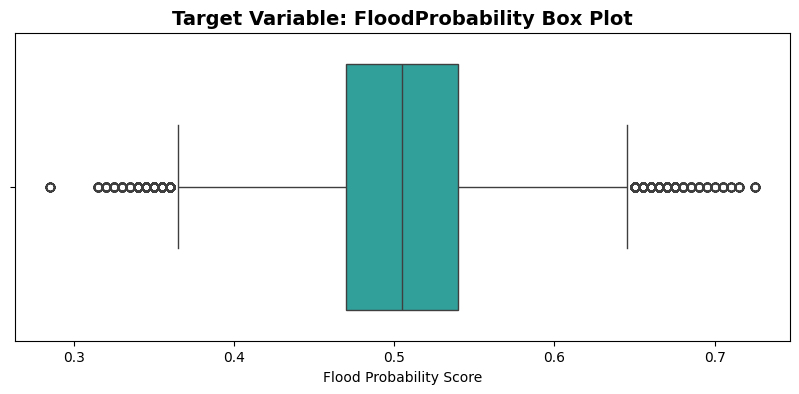

In [16]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_cleaned['FloodProbability'], color='lightseagreen')
plt.title('Target Variable: FloodProbability Box Plot', fontsize=14, weight='bold')
plt.xlabel('Flood Probability Score')
plt.show()


### Case Study: Target Variable Summary Statistics and Distribution
This cell first prints descriptive statistics for the 'FloodProbability' target variable (count, mean, std, min, max, quartiles). Then, it plots a histogram with a KDE to visualize its distribution, allowing for a balance check.

--- Target Summary Statistics ---
count    1.117957e+06
mean     5.044803e-01
std      5.102610e-02
min      2.850000e-01
25%      4.700000e-01
50%      5.050000e-01
75%      5.400000e-01
max      7.250000e-01
Name: FloodProbability, dtype: float64


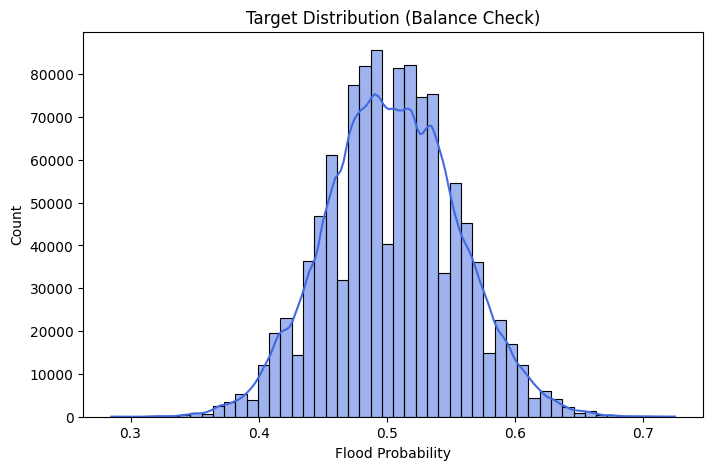

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# Target ke numerical stats check karna
print("--- Target Summary Statistics ---")
print(df['FloodProbability'].describe())

# Distribution Check
plt.figure(figsize=(8, 5))
sns.histplot(df['FloodProbability'], kde=True, bins=50, color='royalblue')
plt.title('Target Distribution (Balance Check)')
plt.xlabel('Flood Probability')
plt.ylabel('Count')
plt.show()


### Case Study: Target Variable Skewness Check
This cell calculates the skewness of the 'FloodProbability' target variable. Skewness indicates the asymmetry of the probability distribution. It then provides a human-readable interpretation of the skewness value, suggesting whether scaling might be needed.

In [18]:
target_skew = df['FloodProbability'].skew()
print(f"FloodProbability Skewness Value: {target_skew:.4f}")

if abs(target_skew) < 0.5:
    print("Result: Data completely balanced aur symmetric hai (Perfect Bell Curve).")
else:
    print("Result: Data skewed (imbalanced distribution) hai, scaling ki zaroorat ho sakti hai.")


FloodProbability Skewness Value: 0.0472
Result: Data completely balanced aur symmetric hai (Perfect Bell Curve).


### Case Study: Prepare Features and Target
This cell separates the dataset into features (`X`) and the target variable (`y`). It drops the 'id' column and the 'FloodProbability' column from `df_cleaned` to form `X`, and assigns the 'FloodProbability' column to `y`.

In [19]:
X = df_cleaned.drop(columns=['id', 'FloodProbability'])
y = df_cleaned['FloodProbability']


### Case Study: Feature Scaling
This cell uses `MinMaxScaler` from `sklearn.preprocessing` to scale the features in `X` to a range between 0 and 1. This is a common preprocessing step for many machine learning models. The scaled features are then converted back into a DataFrame `X_scaled_df`.

In [35]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Scaled array ko wapas DataFrame mein convert karna
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

### Case Study: Split Data into Training and Validation Sets
This cell uses `train_test_split` from `sklearn.model_selection` to divide the scaled features (`X_scaled_df`) and target variable (`y`) into training and validation sets. `test_size=0.2` means 20% of the data is used for validation, and `random_state=42` ensures reproducibility.

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)


Train size: (894365, 20)
Validation size: (223592, 20)


### Case Study: LightGBM Model Training
This cell initializes and trains a LightGBM Regressor model. LightGBM is a gradient boosting framework that uses tree-based learning algorithms. The model is configured with specific hyperparameters like `n_estimators`, `max_depth`, `learning_rate`, etc., and then fitted to the training data (`X_train`, `y_train`).

In [22]:
import lightgbm as lgb

best_model = lgb.LGBMRegressor(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.05,
    num_leaves=15,
    subsample=0.8,
    random_state=42,
    verbose=-1
)

best_model.fit(X_train, y_train)


LGBMRegressor(learning_rate=0.05, max_depth=4, n_estimators=150, num_leaves=15,
              random_state=42, subsample=0.8, verbose=-1)

### Case Study: LightGBM Model Evaluation
This cell evaluates the performance of the trained LightGBM model on the validation set. It calculates several regression metrics: Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score (accuracy percentage). These metrics provide insights into how well the model is performing.

In [23]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

y_pred = best_model.predict(X_val)

mae = mean_absolute_error(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
r2_accuracy = r2_score(y_val, y_pred) * 100

print(f"Model Name: LightGBM Regressor")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score (Accuracy %): {r2_accuracy:.2f}%")


Model Name: LightGBM Regressor
Mean Absolute Error (MAE): 0.0262
Root Mean Squared Error (RMSE): 0.0318
R² Score (Accuracy %): 61.09%


### Case Study: XGBoost Model Training
This cell initializes and trains an XGBoost Regressor model. XGBoost is another popular and efficient implementation of gradient boosting. Similar to LightGBM, it's configured with various hyperparameters and then trained on the `X_train` and `y_train` data.

In [24]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    n_estimators=120,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=120,
             n_jobs=None, num_parallel_tree=None, ...)

### Case Study: XGBoost Model Evaluation
This cell evaluates the performance of the trained XGBoost model on the validation set. It calculates MAE, MSE, RMSE, and R² Score for the XGBoost model, allowing for comparison with other models.

In [25]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

y_pred_xgb = xgb_model.predict(X_val)

mae_xgb = mean_absolute_error(y_val, y_pred_xgb)
mse_xgb = mean_squared_error(y_val, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_val, y_pred_xgb) * 100

print(f"Model Name: XGBoost Regressor")
print(f"Mean Absolute Error (MAE): {mae_xgb:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb:.4f}")
print(f"R² Score (Accuracy %): {r2_xgb:.2f}%")


Model Name: XGBoost Regressor
Mean Absolute Error (MAE): 0.0279
Root Mean Squared Error (RMSE): 0.0339
R² Score (Accuracy %): 55.67%


### Case Study: Linear Regression Model Training
This cell initializes and trains a simple Linear Regression model. This model serves as a baseline for comparison with more complex models like LightGBM and XGBoost. It is fitted to the training data.

In [26]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)


LinearRegression()

### Case Study: Linear Regression Model Evaluation
This cell evaluates the performance of the trained Linear Regression model on the validation set. It calculates MAE, MSE, RMSE, and R² Score for the Linear Regression model, providing a baseline performance metric.

In [27]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

y_pred_lr = linear_model.predict(X_val)

mae_lr = mean_absolute_error(y_val, y_pred_lr)
mse_lr = mean_squared_error(y_val, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_val, y_pred_lr) * 100

print(f"Model Name: Linear Regression (Normal Model)")
print(f"Mean Absolute Error (MAE): {mae_lr:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_lr:.4f}")
print(f"R² Score (Accuracy %): {r2_lr:.2f}%")


Model Name: Linear Regression (Normal Model)
Mean Absolute Error (MAE): 0.0158
Root Mean Squared Error (RMSE): 0.0201
R² Score (Accuracy %): 84.49%


### Case Study: Tuned Random Forest Model (Commented Out)
This cell contains commented-out code for initializing and training a tuned Random Forest Regressor. It includes hyperparameters like `n_estimators` and `max_depth`. Although commented, it indicates an attempt or consideration for a Random Forest model with specific tuning.

In [29]:
# from sklearn.ensemble import RandomForestRegressor

# rf_tuned_model = RandomForestRegressor(
#     n_estimators=50,
#     max_depth=12,
#     random_state=42,
#     n_jobs=-1
# )

# rf_tuned_model.fit(X_train, y_train)


RandomForestRegressor(max_depth=12, n_estimators=50, n_jobs=-1, random_state=42)

### Case Study: Tuned Random Forest Model Evaluation (Commented Out)
This cell contains commented-out code for evaluating the tuned Random Forest model. It would calculate MAE, MSE, RMSE, and R² Score, similar to other models, if uncommented and executed. This provides context for potential model comparisons.

In [30]:
# y_pred_rf_tuned = rf_tuned_model.predict(X_val)

# mae_rf_t = mean_absolute_error(y_val, y_pred_rf_tuned)
# mse_rf_t = mean_squared_error(y_val, y_pred_rf_tuned)
# rmse_rf_t = np.sqrt(mse_rf_t)
# r2_rf_t = r2_score(y_val, y_pred_rf_tuned) * 100

# print(f"Model Name: Tuned Random Forest (Depth=12)")
# print(f"Mean Absolute Error (MAE): {mae_rf_t:.4f}")
# print(f"Root Mean Squared Error (RMSE): {rmse_rf_t:.4f}")
# print(f"R² Score (New Accuracy %): {r2_rf_t:.2f}%")


Model Name: Tuned Random Forest (Depth=12)
Mean Absolute Error (MAE): 0.0305
Root Mean Squared Error (RMSE): 0.0376
R² Score (New Accuracy %): 45.71%


### Case Study: Save Linear Regression Model
This cell uses `joblib` to save the trained `linear_model` to a file named 'linear_regression_model.joblib'. This allows the trained model to be persisted and loaded later for predictions without needing to retrain it.

In [31]:
import joblib

# Model ko save karne ke liye
joblib.dump(linear_model, 'linear_regression_model.joblib')
print("Model successfully saved!")


Model successfully saved!


### Case Study: Load and Predict with Saved Model
This cell demonstrates how to load the previously saved `linear_model` using `joblib.load()`. It then uses the loaded model to make predictions on the validation set (`X_val`) and prints the predictions. This illustrates the process of deploying a saved model.

In [32]:
import joblib

# Model ko wapas load karne ke liye
loaded_model = joblib.load('linear_regression_model.joblib')

# Naye data par prediction karne ka tarika
# Note: X_val ki jagah aap apna naya data (X_new) bhi rakh sakte hain
predictions = loaded_model.predict(X_val)
print(predictions)


[0.53392465 0.58491132 0.5225706  ... 0.53390817 0.49426471 0.50588972]


### Case Study: Save Scaler and Scaled DataFrame
This cell uses `joblib` to save two important preprocessing artifacts: the `MinMaxScaler` (`scaler`) and the `X_scaled_df` DataFrame. Saving the scaler is crucial for consistently scaling new, unseen data before making predictions. Saving the scaled DataFrame allows for quick access to the preprocessed features if needed.

In [36]:
import joblib

# 1. Save the scaler itself (crucial for scaling new test data later)
joblib.dump(scaler, 'minmax_scaler.pkl')

# 2. Save the scaled DataFrame if you want to store the processed data
joblib.dump(X_scaled_df, 'X_scaled_dataframe.pkl')


['X_scaled_dataframe.pkl']